# Chemical Kinetics: Learning Arrhenius Rate from Equilibrium Data

A reversible first-order reaction A <=> B where the forward rate constant depends on temperature via the Arrhenius equation.

**Known structure:**
```
dA/dt = -k_fwd(T) * A + k_rev * B
dB/dt =  k_fwd(T) * A - k_rev * B
```

**Known:** k_rev = 0.1, dt = 0.3, mass conservation A + B = const

**Unknown:** k_fwd(T) = A_prefactor * exp(-E_a / T) -- Arrhenius form, learned as MLP (1->32->32->1, Softplus output)

**Ground truth (hidden):** A_prefactor=2.0, E_a=5.0 (simplified units)

Training on 10 trajectories at temperatures T in [3, 15]. After training: compare learned k_fwd(T) vs true, symbolic regression to recover Arrhenius form, verify mass conservation, check equilibrium ratios.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyBool
from cajal.compiling import compile, TypedTensor

device = torch.device('cpu')

# Ground truth parameters
A_PREFACTOR = 2.0
E_A = 5.0
K_REV = 0.1
DT = 0.3
N_STEPS = 10
N_TRAJ = 10
TEMPERATURES = torch.linspace(3.0, 15.0, N_TRAJ)


def true_k_fwd(T):
    """Arrhenius forward rate constant."""
    return A_PREFACTOR * torch.exp(-E_A / T)


def generate_trajectories():
    all_curves = []
    for T in TEMPERATURES:
        k_f = true_k_fwd(T).item()
        A, B = 1.0, 0.0
        curve = []
        for _ in range(N_STEPS):
            curve.append([A, B, T.item()])
            dA = (-k_f * A + K_REV * B) * DT
            A, B = A + dA, B - dA
        all_curves.append(torch.tensor(curve))
    return torch.stack(all_curves)


data = generate_trajectories()  # (N_TRAJ, N_STEPS, 3)
print(f'Device: {device}')
print(f'Generated {N_TRAJ} trajectories, {N_STEPS} steps each')
print(f'Temperature range: [{TEMPERATURES[0]:.1f}, {TEMPERATURES[-1]:.1f}]')

Device: cpu
Generated 10 trajectories, 10 steps each
Temperature range: [3.0, 15.0]


In [2]:
class ForwardRateMLP(nn.Module):
    """k_fwd: T -> R+. Softplus output enforces positivity."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1), nn.Softplus(),
        )
    def forward(self, T):
        return self.net(T.view(1, 1)).squeeze()


class ReversibleKineticsUpdate(nn.Module):
    """One timestep of A <=> B. State = [A, B, T]."""
    def __init__(self, k_rev, dt, k_fwd_mlp):
        super().__init__()
        self.k_rev, self.dt = k_rev, dt
        self.k_fwd_mlp = k_fwd_mlp

    def forward(self, state):
        A, B, T = state.data[0], state.data[1], state.data[2]
        k_f = self.k_fwd_mlp(T)
        flux = k_f * A - self.k_rev * B
        return TypedTensor(torch.stack([A - flux * self.dt, B + flux * self.dt, T]), state.ty)


# Cajal program
program = TmIter(TmVar('s0'), 's', TmApp(TmVar('f'), TmVar('s')), TmVar('n'))
compiled = compile(program)

mlp = ForwardRateMLP()
update_fn = ReversibleKineticsUpdate(K_REV, DT, mlp)
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.005)

n_params = sum(p.numel() for p in mlp.parameters())
print(f'MLP with {n_params} parameters')

losses = []
for epoch in range(500):
    optimizer.zero_grad()
    total_loss = torch.tensor(0.0)

    for traj_idx in range(N_TRAJ):
        T = TEMPERATURES[traj_idx]
        s0 = TypedTensor(torch.tensor([1.0, 0.0, T.item()]), TyBool())
        for step in range(N_STEPS):
            n_onehot = torch.zeros(N_STEPS)
            n_onehot[step] = 1.0
            result = compiled({'s0': s0, 'f': lambda s, _fn=update_fn: _fn(s),
                               'n': TypedTensor(n_onehot, TyNat())})
            total_loss = total_loss + (result.data[0] - data[traj_idx, step, 0]) ** 2 + \
                                      (result.data[1] - data[traj_idx, step, 1]) ** 2

    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())

    if epoch % 100 == 0 or epoch == 499:
        print(f'  epoch {epoch:3d}  loss={total_loss.item():.8f}')

print('Training complete')

MLP with 1153 parameters
  epoch   0  loss=7.48677444


  epoch 100  loss=0.01677596


  epoch 200  loss=0.00672882


  epoch 300  loss=0.00142185


  epoch 400  loss=0.00016837


  epoch 499  loss=0.00004760
Training complete


In [3]:
# Evaluate learned k_fwd(T)
T_grid = torch.linspace(3.0, 15.0, 50)
with torch.no_grad():
    true_vals = [true_k_fwd(T).item() for T in T_grid]
    learned_vals = [mlp(T).item() for T in T_grid]

max_err = max(abs(t - l) for t, l in zip(true_vals, learned_vals))
print(f'k_fwd(T) max error: {max_err:.4f}')

# Symbolic regression: Arrhenius 2D grid search
T_dense = torch.linspace(3.0, 15.0, 200)
with torch.no_grad():
    learned_dense = torch.tensor([mlp(T).item() for T in T_dense])

arr_best_loss, arr_best_A, arr_best_E = float('inf'), None, None
for A_try in torch.linspace(0.5, 4.0, 80):
    for E_try in torch.linspace(1.0, 10.0, 80):
        pred = A_try * torch.exp(-E_try / T_dense)
        loss = ((pred - learned_dense) ** 2).mean().item()
        if loss < arr_best_loss:
            arr_best_loss, arr_best_A, arr_best_E = loss, A_try.item(), E_try.item()

# Linear candidate
lin_best_loss, lin_best_a = float('inf'), None
for a_try in torch.linspace(0.01, 0.5, 200):
    pred = a_try * T_dense
    loss = ((pred - learned_dense) ** 2).mean().item()
    if loss < lin_best_loss:
        lin_best_loss, lin_best_a = loss, a_try.item()

# Power law candidate
pow_best_loss, pow_best_a, pow_best_b = float('inf'), None, None
for a_try in torch.linspace(0.01, 2.0, 80):
    for b_try in torch.linspace(0.1, 3.0, 80):
        pred = a_try * T_dense ** b_try
        loss = ((pred - learned_dense) ** 2).mean().item()
        if loss < pow_best_loss:
            pow_best_loss, pow_best_a, pow_best_b = loss, a_try.item(), b_try.item()

print(f'\nSymbolic regression results:')
print(f'  Arrhenius A*exp(-E/T): A={arr_best_A:.3f}, E={arr_best_E:.3f}  MSE={arr_best_loss:.6f}')
print(f'  Linear a*T:            a={lin_best_a:.3f}                     MSE={lin_best_loss:.6f}')
print(f'  Power a*T^b:           a={pow_best_a:.3f}, b={pow_best_b:.3f}  MSE={pow_best_loss:.6f}')

best_name = 'Arrhenius' if arr_best_loss <= min(lin_best_loss, pow_best_loss) else \
            'Linear' if lin_best_loss <= pow_best_loss else 'Power'
print(f'\n  BEST: {best_name}')
if best_name == 'Arrhenius':
    print(f'  True:    A={A_PREFACTOR:.3f}, E_a={E_A:.3f}')
    print(f'  Learned: A={arr_best_A:.3f}, E_a={arr_best_E:.3f}')

# Compute symbolic prediction for plotting
sym_pred = arr_best_A * torch.exp(-arr_best_E / T_dense)

# Verification
all_positive = True
mass_conserved = True
with torch.no_grad():
    for traj_idx in range(N_TRAJ):
        T = TEMPERATURES[traj_idx]
        s0 = TypedTensor(torch.tensor([1.0, 0.0, T.item()]), TyBool())
        for step in range(N_STEPS):
            n_onehot = torch.zeros(N_STEPS)
            n_onehot[step] = 1.0
            result = compiled({'s0': s0, 'f': lambda s, _fn=update_fn: _fn(s),
                               'n': TypedTensor(n_onehot, TyNat())})
            A_val, B_val = result.data[0].item(), result.data[1].item()
            if A_val < -1e-8 or B_val < -1e-8: all_positive = False
            if abs((A_val + B_val) - 1.0) > 1e-4: mass_conserved = False

print(f'\nVERIFICATION:')
print(f"  A >= 0, B >= 0:          {'VERIFIED' if all_positive else 'FAILED'}")
print(f"  A + B = 1.0 (mass cons): {'VERIFIED' if mass_conserved else 'FAILED'}")

# Equilibrium analysis
eq_data = []
with torch.no_grad():
    for T in TEMPERATURES:
        k_f = mlp(T).item()
        expected_ratio = K_REV / k_f
        s = TypedTensor(torch.tensor([1.0, 0.0, T.item()]), TyBool())
        for _ in range(200):
            s = update_fn(s)
        A_eq, B_eq = s.data[0].item(), s.data[1].item()
        sim_ratio = A_eq / B_eq if B_eq > 1e-10 else float('inf')
        eq_data.append((T.item(), k_f, expected_ratio, sim_ratio))

print(f'\nEQUILIBRIUM ANALYSIS:')
print(f"  {'T':>6s}  {'k_fwd':>8s}  {'Expected A/B':>12s}  {'Simulated A/B':>13s}")
for T, k_f, exp_r, sim_r in eq_data:
    print(f'  {T:6.2f}  {k_f:8.4f}  {exp_r:12.4f}  {sim_r:13.4f}')

k_fwd(T) max error: 0.0065

Symbolic regression results:
  Arrhenius A*exp(-E/T): A=2.006, E=4.987  MSE=0.000030
  Linear a*T:            a=0.113                     MSE=0.020527
  Power a*T^b:           a=0.262, b=0.651  MSE=0.003096

  BEST: Arrhenius
  True:    A=2.000, E_a=5.000
  Learned: A=2.006, E_a=4.987

VERIFICATION:
  A >= 0, B >= 0:          VERIFIED
  A + B = 1.0 (mass cons): VERIFIED



EQUILIBRIUM ANALYSIS:
       T     k_fwd  Expected A/B  Simulated A/B
    3.00    0.3782        0.2644         0.2644
    4.33    0.6292        0.1589         0.1589
    5.67    0.8299        0.1205         0.1205
    7.00    0.9786        0.1022         0.1022
    8.33    1.0961        0.0912         0.0912
    9.67    1.1922        0.0839         0.0839
   11.00    1.2710        0.0787         0.0787
   12.33    1.3354        0.0749         0.0749
   13.67    1.3876        0.0721         0.0721
   15.00    1.4300        0.0699         0.0699


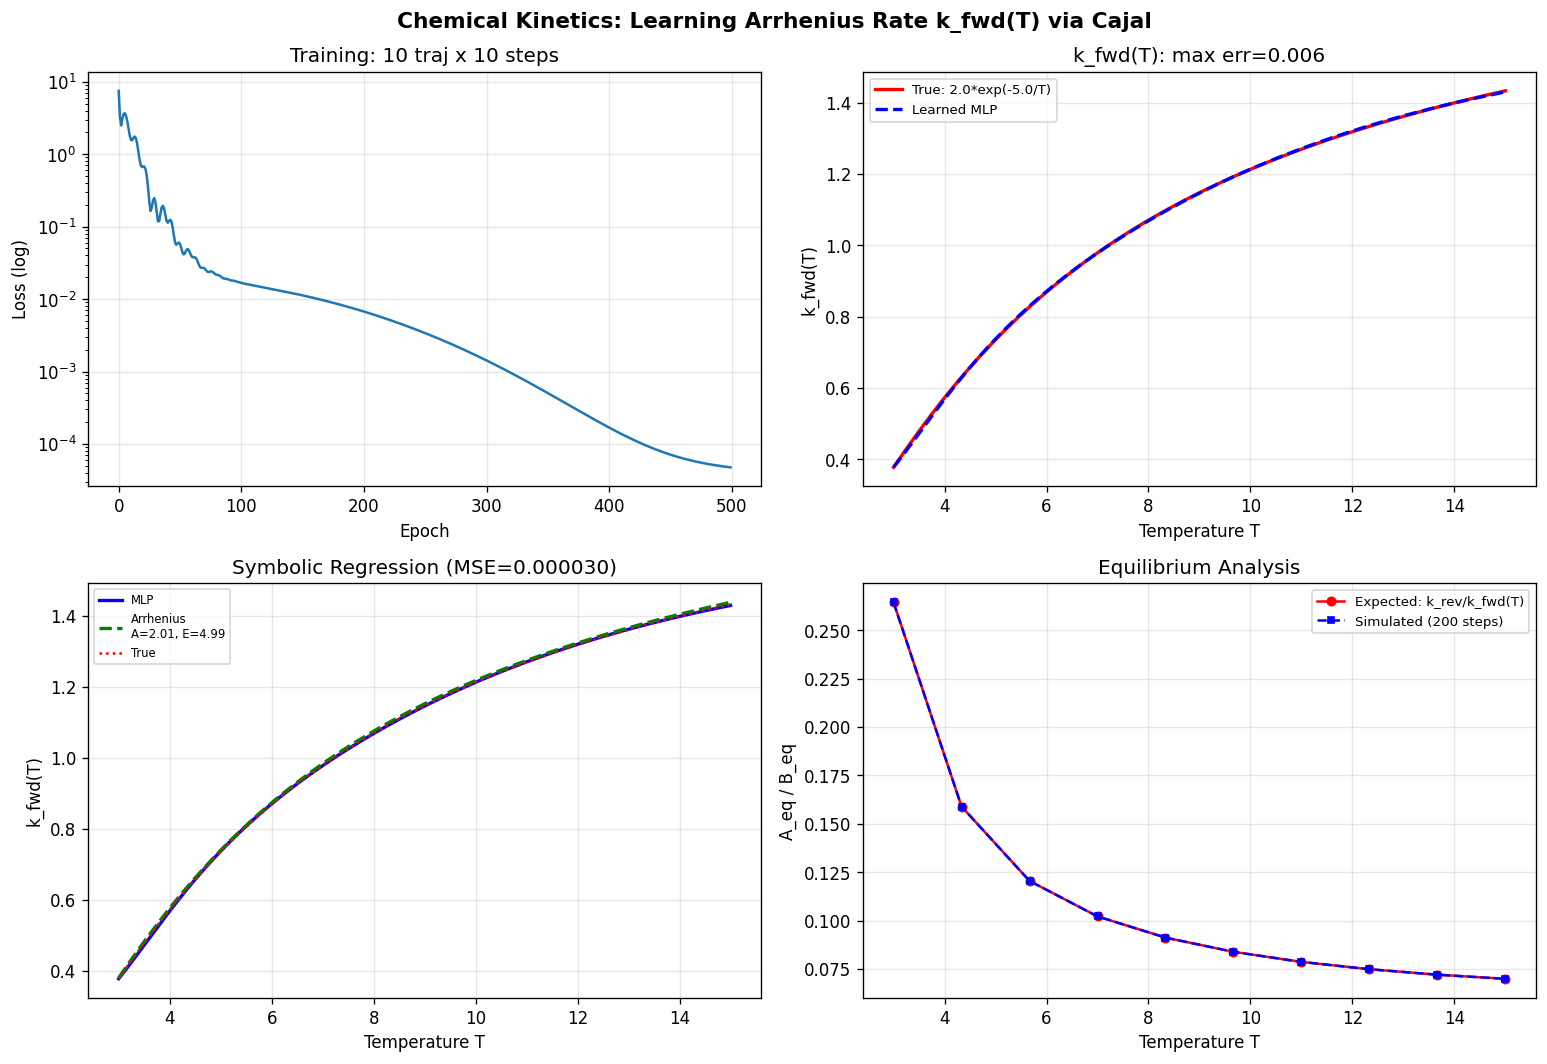

In [4]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Training loss
axes[0, 0].semilogy(losses)
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss (log)')
axes[0, 0].set_title(f'Training: {N_TRAJ} traj x {N_STEPS} steps')
axes[0, 0].grid(True, alpha=0.3)

# (2) Learned k_fwd(T) vs true
axes[0, 1].plot(T_grid.numpy(), true_vals, 'r-', lw=2, label=f'True: {A_PREFACTOR}*exp(-{E_A}/T)')
axes[0, 1].plot(T_grid.numpy(), learned_vals, 'b--', lw=2, label='Learned MLP')
axes[0, 1].set_xlabel('Temperature T'); axes[0, 1].set_ylabel('k_fwd(T)')
axes[0, 1].set_title(f'k_fwd(T): max err={max_err:.3f}')
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, alpha=0.3)

# (3) Symbolic regression fit
axes[1, 0].plot(T_dense.numpy(), learned_dense.numpy(), 'b-', lw=2, label='MLP')
axes[1, 0].plot(T_dense.numpy(), sym_pred.numpy(), 'g--', lw=2,
                label=f'Arrhenius\nA={arr_best_A:.2f}, E={arr_best_E:.2f}')
axes[1, 0].plot(T_dense.numpy(), [true_k_fwd(T).item() for T in T_dense],
               'r:', lw=1.5, label='True')
axes[1, 0].set_xlabel('Temperature T'); axes[1, 0].set_ylabel('k_fwd(T)')
axes[1, 0].set_title(f'Symbolic Regression (MSE={arr_best_loss:.6f})')
axes[1, 0].legend(fontsize=7); axes[1, 0].grid(True, alpha=0.3)

# (4) Equilibrium A/B ratios
T_eq = [d[0] for d in eq_data]
expected_ratios = [d[2] for d in eq_data]
sim_ratios = [d[3] for d in eq_data]
axes[1, 1].plot(T_eq, expected_ratios, 'ro-', markersize=5, label='Expected: k_rev/k_fwd(T)')
axes[1, 1].plot(T_eq, sim_ratios, 'bs--', markersize=4, label='Simulated (200 steps)')
axes[1, 1].set_xlabel('Temperature T'); axes[1, 1].set_ylabel('A_eq / B_eq')
axes[1, 1].set_title('Equilibrium Analysis')
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Chemical Kinetics: Learning Arrhenius Rate k_fwd(T) via Cajal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chemical_kinetics_results.png', dpi=120, bbox_inches='tight')
plt.show()